# BT4221 Project Group 4 — Spark Post-Cleaning EDA

**Note:** This notebook performs Exploratory Data Analysis with the `cleaned_parquet.parquet` parquet created from the `EDA.ipynb` file.  
The parquet file **must** be available in your local directory to successfully run this notebook.

## Problem Statement and Class Definition

Traffic congestion and road safety are critical issues for urban planning and emergency response management. This project leverages a countrywide dataset of US traffic accidents, spanning 49 states and collected via real-time traffic APIs from 2016 to 2023. The primary objective is to determine whether the severity of an accident, gauged by its impact on traffic flow, can be accurately predicted using real-time environmental, temporal, and spatial conditions.

The original dataset records accident severity on a scale from 1 to 4 of increasing traffic delay. To manage severe class imbalance and focus on identifying factors that lead to significant traffic disruption, the target is reclassified into a binary variable:

*   Low Severity (high_severity = 0): Original levels 1 and 2, representing accidents with minor to moderate impact on traffic flow.
*   High Severity (high_severity =  1): Original levels 3 and 4, representing accidents with significant impact on traffic flow.

The following notebook illustrates the Exploratory Data Analysis on the binarised severity classes to investigate underlying patterns in the dataset before the data enters the automated data pipeline executed by LLM agents.

In [1]:
# Visual helper function (Only for printing purposes) 
def border(s):
    print(f"{'='*20} {s} {'='*20}")

## Environment Setup

### Google Colab
Run if you are using Google Colab

In [ ]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [ ]:
# Download and install Spark
border("Install dependencies")
!pip3 install pyspark

# Install findspark
!pip3 install findspark

# Initialise findspark
import findspark
findspark.init()

# Set java version
# import os
# java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# os.environ['JAVA_HOME'] = java_path

# Verify installation
border("PySpark Version")
!pip show pyspark
border("findspark Version")
!pip show findspark
border("Hadoop version")
!hadoop version
border("Java version")
!java -version

## Import Libaries

In [ ]:
# Import required libraries
from pyspark.sql import SparkSession

import pyspark.sql.functions as F

from pyspark.sql.types import StringType, IntegerType, DoubleType, BooleanType
from pyspark.sql.window import Window

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer

from pathlib import Path
import psutil
import os

# Visulisations only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Initialise SparkSession

### Dynamic SparkSession Configuration

In [4]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 20
Driver Memory: 44g


### Create SparkSession

The following SparkSession aims to achieve greater resource allocation, parallelism, and adaptive query execution:
* Resource Allocation
    * **master("local[*]")**  
    Ensures Spark runs locally using all available CPU cores for heavy data processing
* Parallelism
    * **config("spark.default.parallelism", cores)**  
    The number of partitions for oeprations dynamically matches local hardware 
    * **config("spark.sql.shuffle.partitions", cores * 3)**  
    Instead of using Spark's default number of 200 partitions, we set partitions to be 3 * cores to ensure CPUs stay busy with the remaining partitions even if some tasks finish earlier
* Adaptive Query Execution
    * **config("spark.sql.adaptive.enabled", "true")**  
    Allow Spark to reoptimise the query plan during execution based on data statistics. For instance, by switching from a slower Shuffle (eg. Sort-Merge Join) to a faster one (eg. Broadcasr Hash Join)
    * **config("spark.sql.adaptive.skewJoin.enabled", "true")**  
    Allow Spark to detect heavy partitions and split it into smaller pieces so the slowest task does not stall the entire job. For instance in this dataset, we will frequently encounter extremely skewed keys (eg. State California, Street I-95) and so it is necessary to mitigate their impact on Spark performance.

In [5]:
# Create SparkSession 
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BT4221_Group4") \
    .config("spark.driver.memory", driver_memory) \
    .config("spark.sql.shuffle.partitions", cores * 3) \
    .config("spark.default.parallelism", cores) \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .getOrCreate()

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

App: BT4221_Group4


## Read Parquet

In [ ]:
# Read directories
PROJECT_ROOT = Path.cwd().parent
CLEANED_PARQUET_PATH = PROJECT_ROOT / "dataset/visual.parquet"

if not CLEANED_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {CLEANED_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", CLEANED_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(CLEANED_PARQUET_PATH))
df.cache()

Project root: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj
Original Parquet: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj\dataset\visual_parquet


DataFrame[Airport_Code: string, Start_Time_Month: int, Severity: int, Start_Time: timestamp, End_Time: timestamp, Start_Lat: double, Start_Lng: double, Distance(mi): double, Street: string, City: string, County: string, State: string, Zipcode: string, Timezone: string, Temperature(F): double, Humidity(%): double, Pressure(in): double, Visibility(mi): double, Wind_Direction: string, Wind_Speed(mph): double, Precipitation(in): double, Weather_Condition: string, Crossing: boolean, Junction: boolean, Station: boolean, Stop: boolean, Traffic_Signal: boolean, Sunrise_Sunset: string, Civil_Twilight: string, Nautical_Twilight: string, Astronomical_Twilight: string, Start_Time_Year: int, Start_Time_Day_of_Week: int, Start_Time_Hour: int, Start_Time_is_Weekend: int, End_Time_Year: int, End_Time_Month: int, End_Time_Day_of_Week: int, End_Time_Hour: int, End_Time_is_Weekend: int, Duration_Seconds: bigint, high_severity: int]

## Categorise Columns

In [7]:
# Categorise column types
numerical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType))]
bool_col = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
categorical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType) and f.name != "ID"]

print(f"Numerical columns: {numerical_col}")
print(f"Boolean columns: {bool_col}")
print(f"Categorical columns: {categorical_col}")

Numerical columns: ['Start_Time_Month', 'Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Start_Time_Year', 'Start_Time_Day_of_Week', 'Start_Time_Hour', 'Start_Time_is_Weekend', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend', 'high_severity']
Boolean columns: ['Crossing', 'Junction', 'Station', 'Stop', 'Traffic_Signal']
Categorical columns: ['Airport_Code', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## Analysis for Severity Correlation

### Compare Spatial and Meteorological Feature Means across Binarised Severity

In [8]:
weather_spatial = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Distance(mi)", "Start_Lat", "Start_Lng"]

time_based = ["Start_Time_Month", "Start_Time_Day_of_Week", "Start_Time_Hour", "Start_Time_is_Weekend"]

skip = ["Severity", "high_severity", "Start_Time_Year", "End_Time_Year", "End_Time_Month", "End_Time_Day_of_Week", "End_Time_Hour", "End_Time_is_Weekend"]


# Table for weather/spatial means 
numerical_df = df.groupBy("high_severity").agg(
    *[F.round(F.mean(c), 4).alias(c) for c in weather_spatial]
).orderBy("high_severity")

numerical_pd = numerical_df.toPandas()
numerical_pd["high_severity"] = numerical_pd["high_severity"].map({0: "Low severity", 1: "High severity"})
numerical_pd = numerical_pd.set_index("high_severity").T
print(numerical_pd.to_string())


high_severity      Low severity  High severity
Temperature(F)          61.7546        61.6306
Humidity(%)             64.7152        65.7398
Pressure(in)            29.5253        29.6554
Visibility(mi)           9.0983         9.0926
Wind_Speed(mph)          7.5246         8.0447
Precipitation(in)        0.0057         0.0085
Distance(mi)             0.5240         0.4792
Start_Lat               36.0248        36.8435
Start_Lng              -94.7827       -93.0621


#### Notable Observations


* Temperature(F), Pressure(in), Visibility(mi), and Distance(mi) are similar across low and high severity (differences in the second or third decimal place)
* Humidity% shows the most noticeable difference (64.7152 < 65.7398). Higher severity incidents may occur in slightly more humid conditions.
* Wind_Speed(mph) shows the second most noticeable difference (7.5246 < 8.0447). Higher severity incidents may occur in slightly more windy conditions.
* Precipitation(in) is slightly higher for high severity (0.0057 < 0.0085), but both values are extremely close to 0, indicating most accidents happen in dry conditions regardless of severity.

### Compare Weather Features across Binarised Severity

In [9]:
# Table of Weather Feature means and total num of low/high severity accidents by Start_Time_Month
weather_cols = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
agg_ops = [F.round(F.avg(F.col(c)), 2).alias(f"Avg_{c}") for c in weather_cols]

monthly_weather_severities = df \
    .select(weather_spatial + ["high_severity", "Start_Time_Month"]) \
    .groupBy("Start_Time_Month", "high_severity") \
    .agg(
        F.count("*").alias("Total_Accidents"),
        *agg_ops
    ) \
    .orderBy("Start_Time_Month", "high_severity")

monthly_weather_severities.cache()

border("Monthly Total High Severity Accidents and Weather Feature Means")
monthly_weather_severities.filter(F.col("high_severity") == 1).show()

border("Monthly Total Low Severity Accidents and Weather Feature Means")
monthly_weather_severities.filter(F.col("high_severity") == 0).show()

monthly_pd = monthly_weather_severities.toPandas()
pivoted = monthly_pd.pivot(index='Start_Time_Month', columns='high_severity')
pivoted.columns = [f"{col[0]}_{int(col[1])}" for col in pivoted.columns]
pivoted['High_Sev_Rate'] = pivoted['Total_Accidents_1'] / (pivoted['Total_Accidents_0'] + pivoted['Total_Accidents_1'])

==================== Monthly Total High Severity Accidents and Weather Feature Means ====================
+----------------+-------------+---------------+------------------+---------------+----------------+------------------+-------------------+---------------------+
|Start_Time_Month|high_severity|Total_Accidents|Avg_Temperature(F)|Avg_Humidity(%)|Avg_Pressure(in)|Avg_Visibility(mi)|Avg_Wind_Speed(mph)|Avg_Precipitation(in)|
+----------------+-------------+---------------+------------------+---------------+----------------+------------------+-------------------+---------------------+
|               1|            1|         117791|             42.39|           69.4|           29.77|              8.52|               8.38|                 0.01|
|               2|            1|         111740|             44.93|          69.18|           29.74|              8.32|               8.68|                 0.01|
|               3|            1|         109889|              52.8|           63.0| 

* In the coldest month (January), high severity accidents occur at a lower average temperature (42.39F) than low severity ones (45.97F).
* The Winter months (Nov, Dec, Jan) consistently sees high severity counts at about 120k incidents despite the overall drop in temperatures. In comparison, low severity counts show a clear increase in Winter months and decrease in Summer months.
* As expected, average Temperature(F) and Visibility(mi) show the most significant seasonal changes, likely due to weather conditions such as snow, fog, or freezing rain.

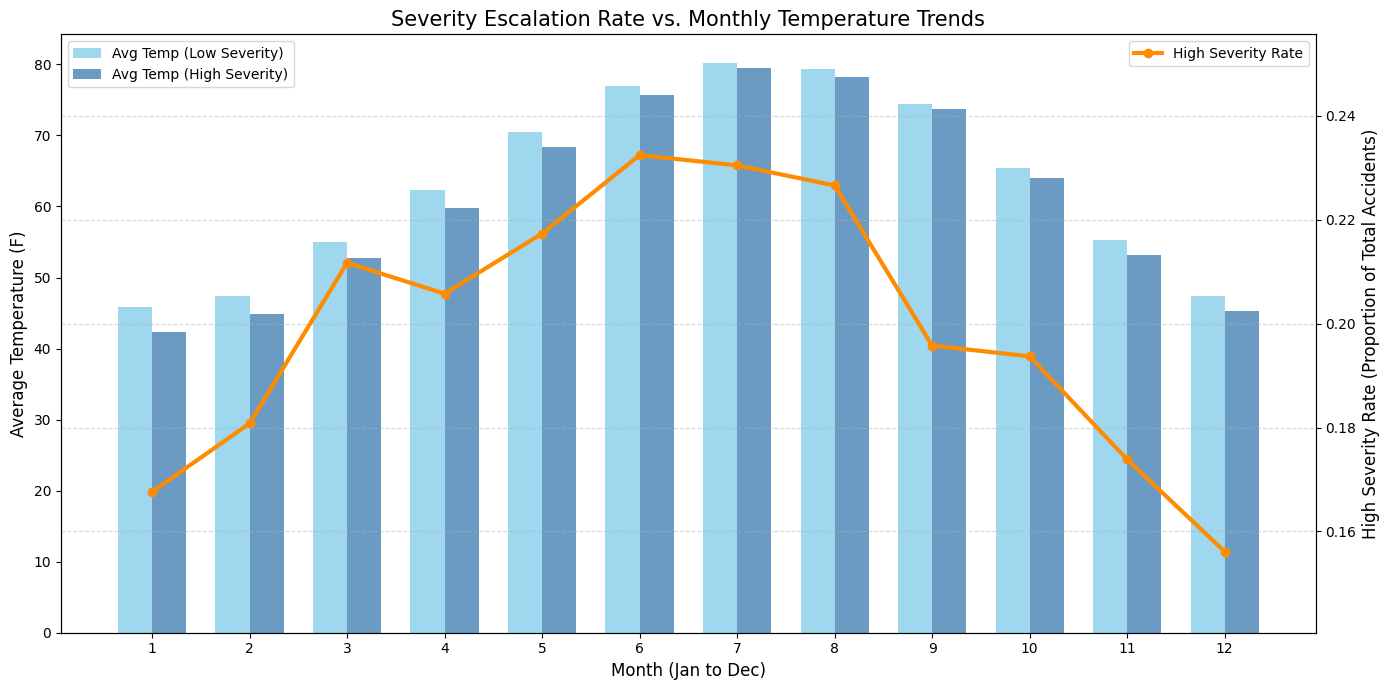

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 7))

months = pivoted.index
width = 0.35
ax1.bar(months - width/2, pivoted['Avg_Temperature(F)_0'], width, label='Avg Temp (Low Severity)', color='skyblue', alpha=0.8)
ax1.bar(months + width/2, pivoted['Avg_Temperature(F)_1'], width, label='Avg Temp (High Severity)', color='steelblue', alpha=0.8)

ax1.set_xlabel('Month (Jan to Dec)', fontsize=12)
ax1.set_ylabel('Average Temperature (F)', fontsize=12)
ax1.set_title('Severity Escalation Rate vs. Monthly Temperature Trends', fontsize=15)
ax1.set_xticks(months)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(months, pivoted['High_Sev_Rate'], color='darkorange', marker='o', linewidth=3, label='High Severity Rate')

ax2.set_ylabel('High Severity Rate (Proportion of Total Accidents)', fontsize=12)
ax2.set_ylim(pivoted['High_Sev_Rate'].min() * 0.9, pivoted['High_Sev_Rate'].max() * 1.1)
ax2.legend(loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Notable Observations

* Within each month, the average temperature for a high severity accident is consistently lower than that of a low severity accident. 
    * This suggests that accidents occurring in colder micro-climates are more likely to escalate in severity.
* However, the high severity rate dips in the coldest winter months (Dec/Jan) compared to the summer peak (June/July)
    * This suggests that low severity frequency is greater in the Winter months.

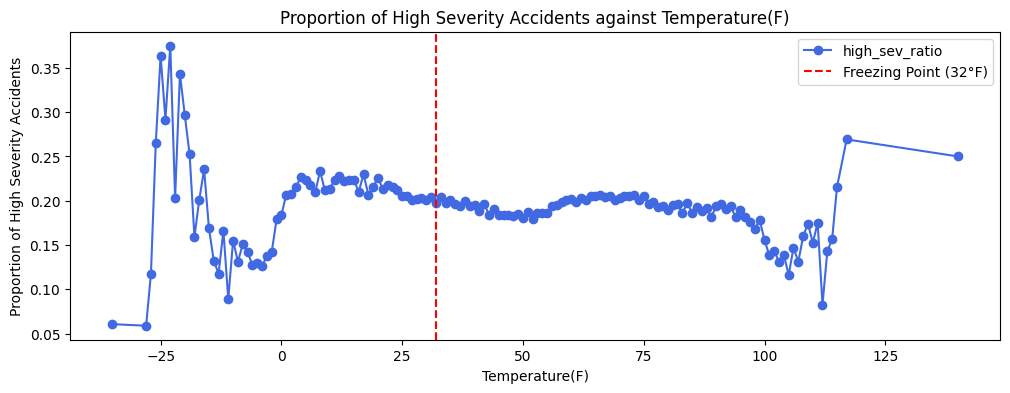

In [12]:
# Ratio of High Severity Accidents per degree of Temperature (F)
temperature_df = df.select("Temperature(F)", "high_severity") \
    .withColumn("Temp_Rounded", F.round(F.col("Temperature(F)"), 0)) \
    .groupBy("Temp_Rounded") \
    .agg(
        F.count("*").alias("total_accidents"),
        F.sum(F.col("high_severity")).alias("high_sev_count")
    ) \
    .withColumn("high_sev_ratio", F.col("high_sev_count") / F.col("total_accidents")) \
    .filter(F.col("total_accidents") > 10) \
    .orderBy("Temp_Rounded")

temperature_pd = temperature_df.toPandas()

plt.figure(figsize=(12, 4))

plt.plot("Temp_Rounded", "high_sev_ratio", marker="o", data=temperature_pd, color="royalblue")

plt.xlabel("Temperature(F)")
plt.ylabel("Proportion of High Severity Accidents")
plt.title(f"Proportion of High Severity Accidents against Temperature(F)")
plt.axvline(x=32, color='red', linestyle='--', label='Freezing Point (32°F)')
plt.legend()
plt.show()


#### Notable Observations

* As the temperature drops below 30F, the proportion of high severity accidents climbs sharply. 
    * This supports the earlier observation that while there are fewer cars on the road in freezing conditions, accidents that do occur are more likely to be high severity.
    * Possibly due to black ice, reduced traction, or lower visibility.
* Between 40F and 80F, the ratio remains relatively flat.
    * In this range, severity is likely driven by other factors instead of extreme environmental conditions

### Compare Temporal Features across Binarised Severity

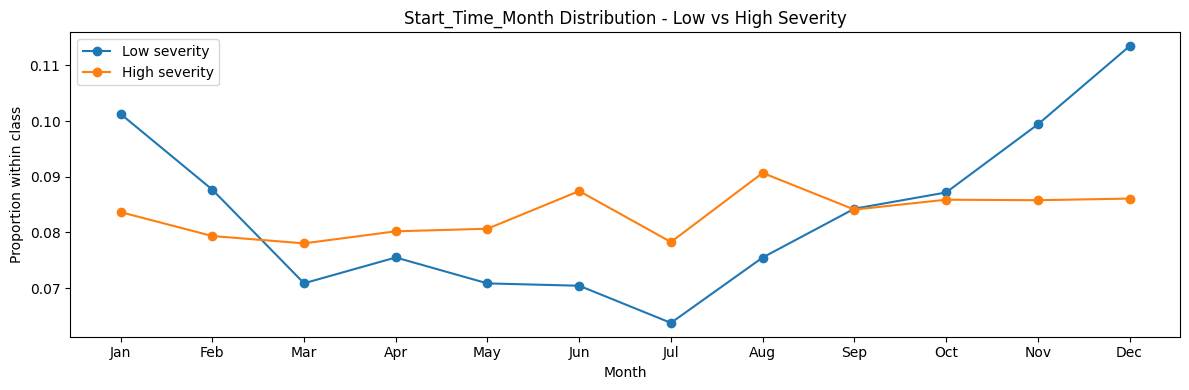

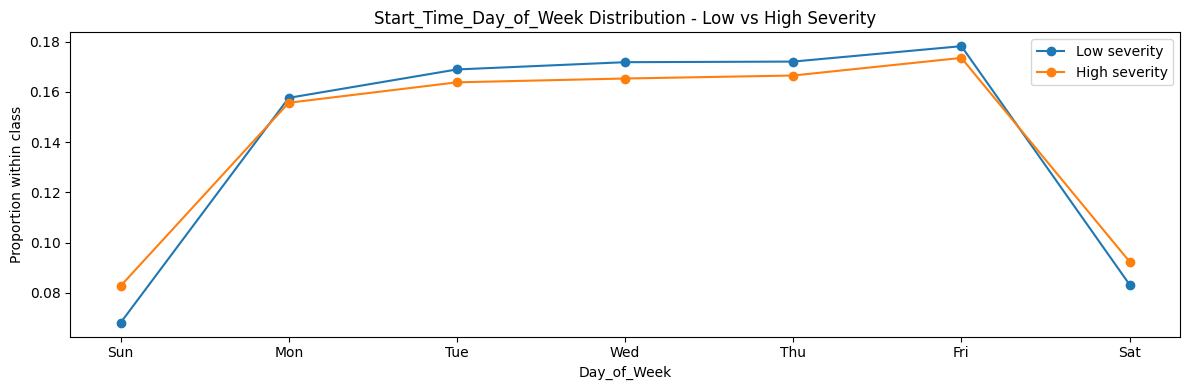

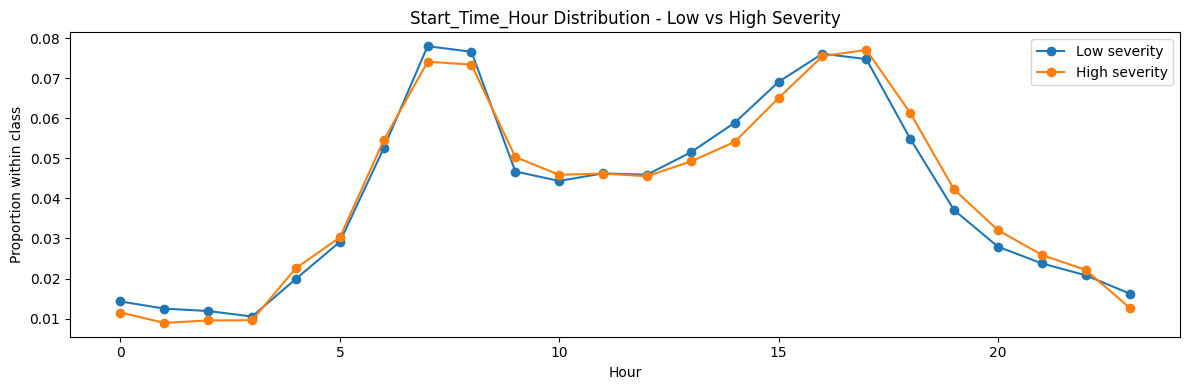

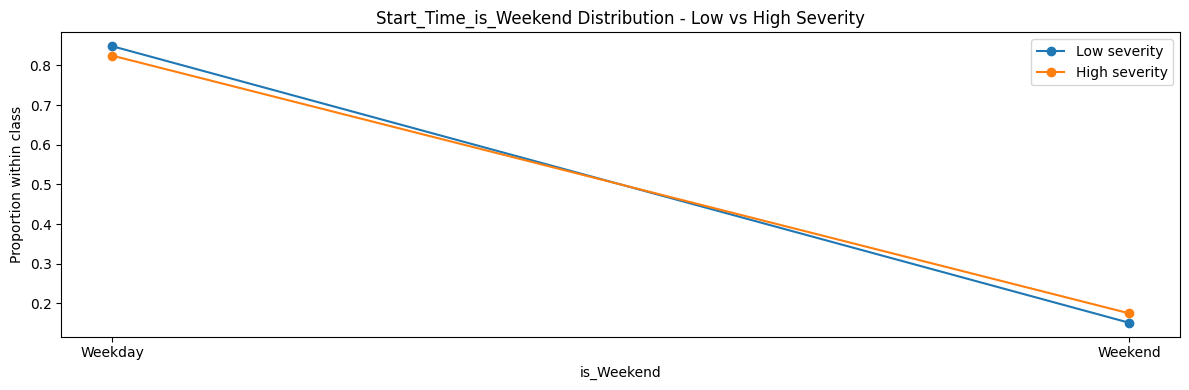

In [9]:
for time_col in time_based:
    time_df = df.groupBy("high_severity", time_col).count()
    window_spec = Window.partitionBy("high_severity")
    
    time_df = time_df.withColumn(
        "pct", F.col("count") / F.sum("count").over(window_spec)
    )
    
    time_pd = time_df.toPandas()

    plt.figure(figsize=(12, 4))
    
    severity_labels = {0: "Low severity", 1: "High severity"}
    
    for sev in [0, 1]:
        sub = time_pd[time_pd["high_severity"] == sev].sort_values(time_col)
        plt.plot(sub[time_col], sub["pct"], marker="o", label=severity_labels[sev])
    
    plt.xlabel(time_col.replace("Start_Time_", ""))
    plt.ylabel("Proportion within class")
    plt.title(f"{time_col} Distribution - Low vs High Severity")
    plt.legend()

    if time_col == "Start_Time_Month":
        plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    elif time_col == "Start_Time_Day_of_Week":
        plt.xticks(range(1, 8), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
    elif time_col == "Start_Time_is_Weekend":
        plt.xticks([0, 1], ["Weekday", "Weekend"])

    plt.tight_layout()
    plt.show()

* Overall, Low and High severity accidents follow similar distributions across the Day of the Week, Hour, and whether the day Is a Weekend.
* By Month
    * High severity incidents occur relatively consistently throughout the year as the line stays with the range of approximately [0.075, 0.09], with slight peaks in June (~0.09) and August (~0.09).
    * Low severity 
        * Accidents trend upward from September through to the winter months of October to December.
        * Accident frequency peaks in December (~0.113)
        * These findings correlate with the observations before that Winter months tend to lead to an increase in low severity frequency
        * Accidents remain relatively low from March to August of the Spring and Summer months.

This suggests that the impact of seasonality on accident frequency is significant for Low severity incidents, but less so for High severity incidents.

* By Day_of_Week
    * Both severity levels have relatively consistent similar accident frequencies across the week, with more accidents on weekdays than weekends.
    * There is a slight increase in accident frequencies from Monday to Friday.
* By Hour
    * Both severity levels follow similar M-shaped distributions, with peaks at the morning (0700-0800) and evening rush hours (1600 -1700).

### Compare Boolean Features across Binarised Severity

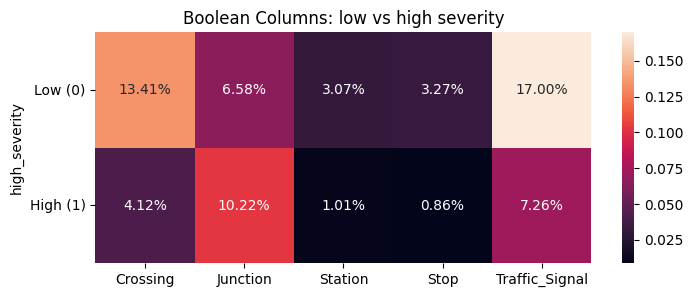

In [10]:
rate = df.groupBy("high_severity").agg(
    *[F.round(F.mean(F.col(p).cast("int")), 4).alias(p) for p in bool_col]
).orderBy("high_severity").toPandas().set_index("high_severity")

plt.figure(figsize=(8, 3))
sns.heatmap(rate, annot=True, fmt=".2%")
plt.title("Boolean Columns: low vs high severity")
plt.yticks([0.5, 1.5], ["Low (0)", "High (1)"], rotation=0)
plt.show()

#### Notable Observations


* Crossing
    * More common in Low severity (13.41% vs 4.12%). 
    * It is possible that such accidents are concentrated in urban areas where traffic speeds are lower, causing lower severities.
* Junction
    * More common in High severity (10.22% vs 6.58%). 
    * It is possible that junctions involve more complex, high-speed maneuvering that results in more critical impacts in accidents.
* Station
    * More common in Low severity (3.07% vs 1.01%). 
    * It is possible that these incidents occur near public transit hubs during peak travel times, such as morning commutes.
* Stop
    * More common in Low severity (3.27% vs 0.86%). 
    * It is possible that vehicles are already travelling at lower speeds near stops, leading to lower vehicle impact in accidents.
* Traffic Signal
    * Notably more common in Low severity (17.00% vs 7.26%). 
    * It is possible that controlled intersections enable greater control of traffic disruption.

The heatmap suggests that infrastructure type influences severity level and Junction appears associated with higher severity accidents.

### Compare Categorical Features across Binarised Severity


==================== Airport_Code distribution — low vs high severity (Top 20) ====================


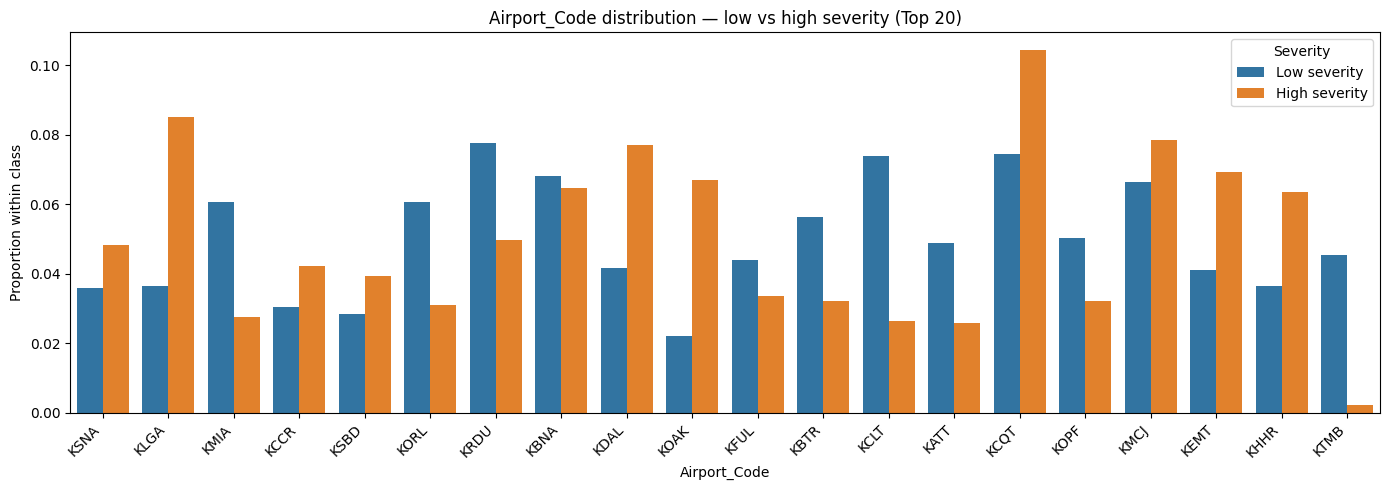


==================== Street distribution — low vs high severity (Top 20) ====================


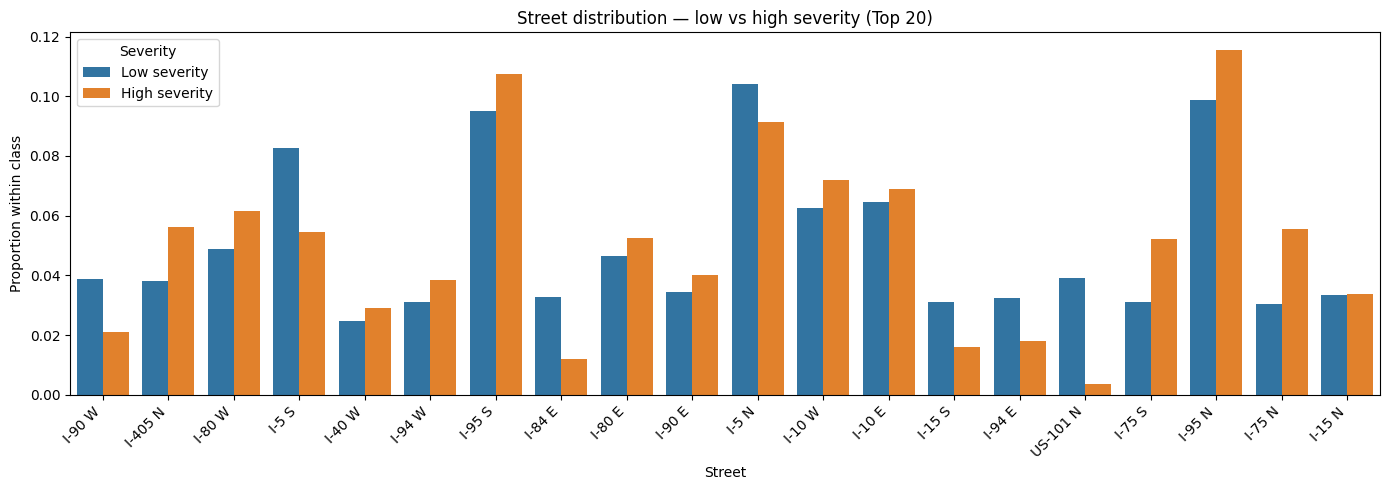


==================== City distribution — low vs high severity (Top 20) ====================


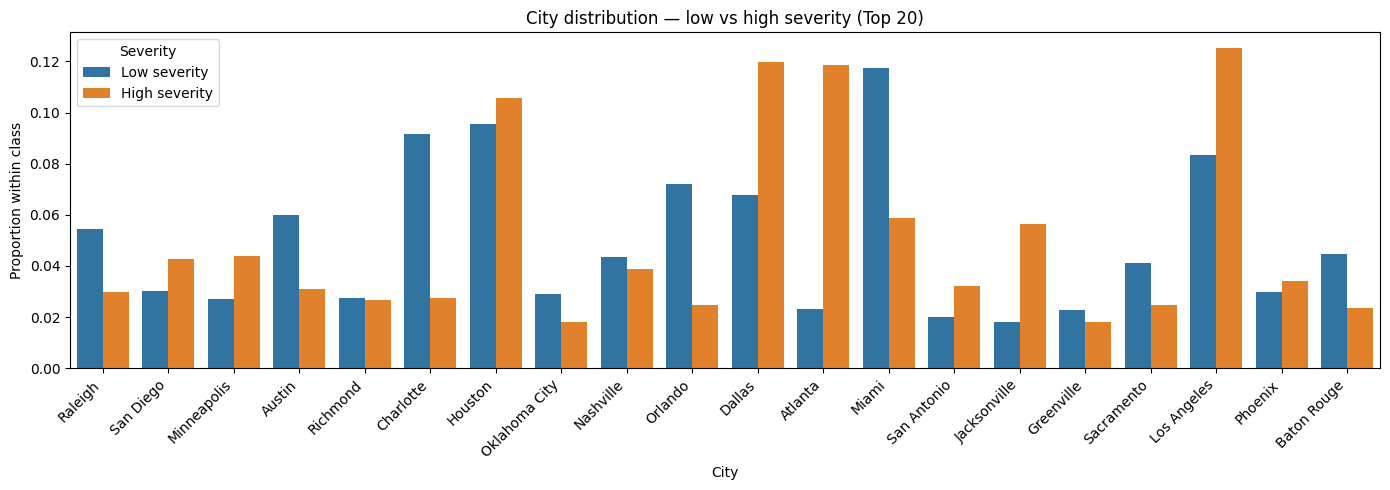


==================== County distribution — low vs high severity (Top 20) ====================


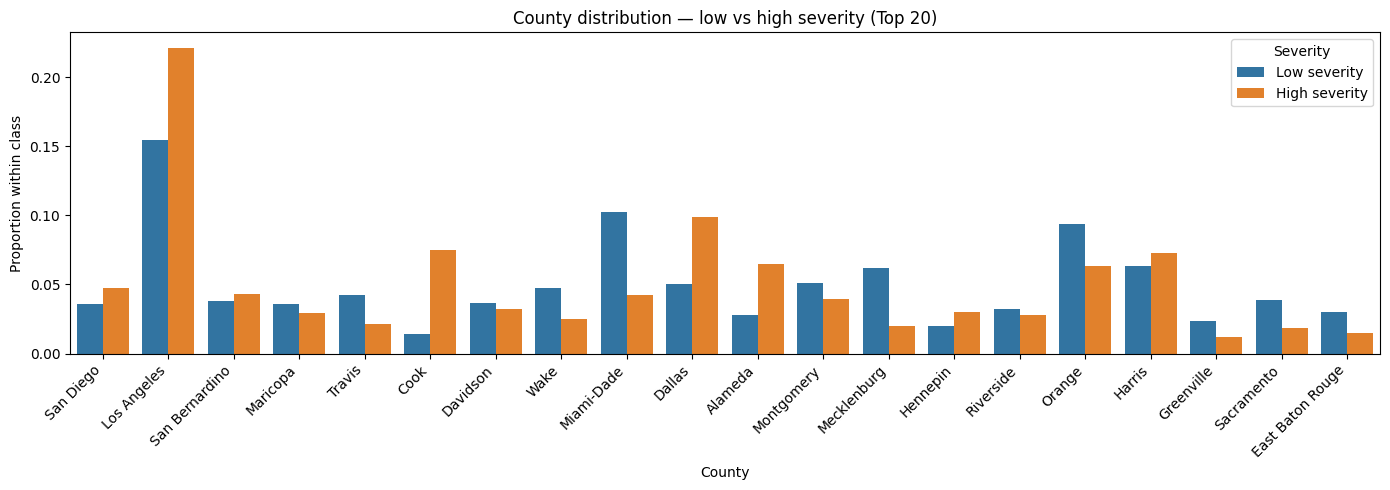


==================== State distribution — low vs high severity (Top 20) ====================


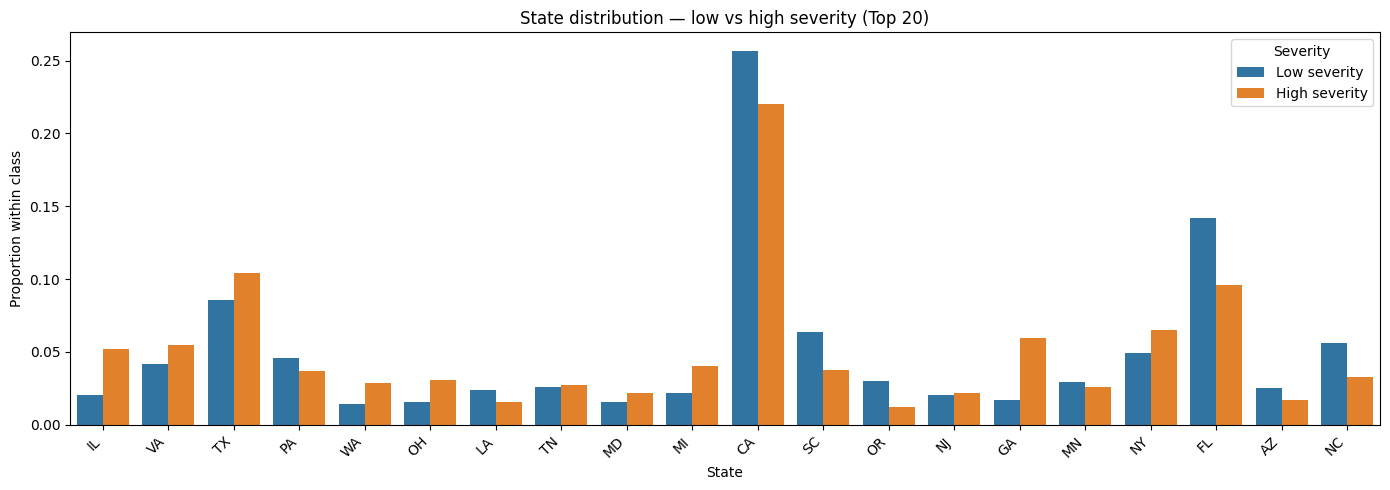


==================== Zipcode distribution — low vs high severity (Top 20) ====================


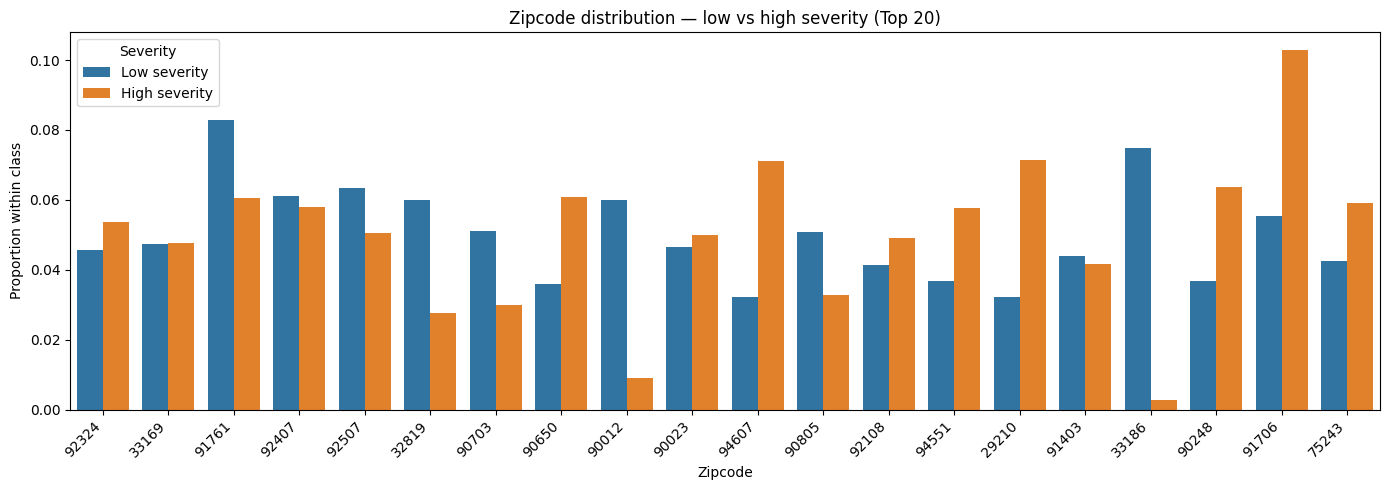


==================== Timezone distribution — low vs high severity  ====================


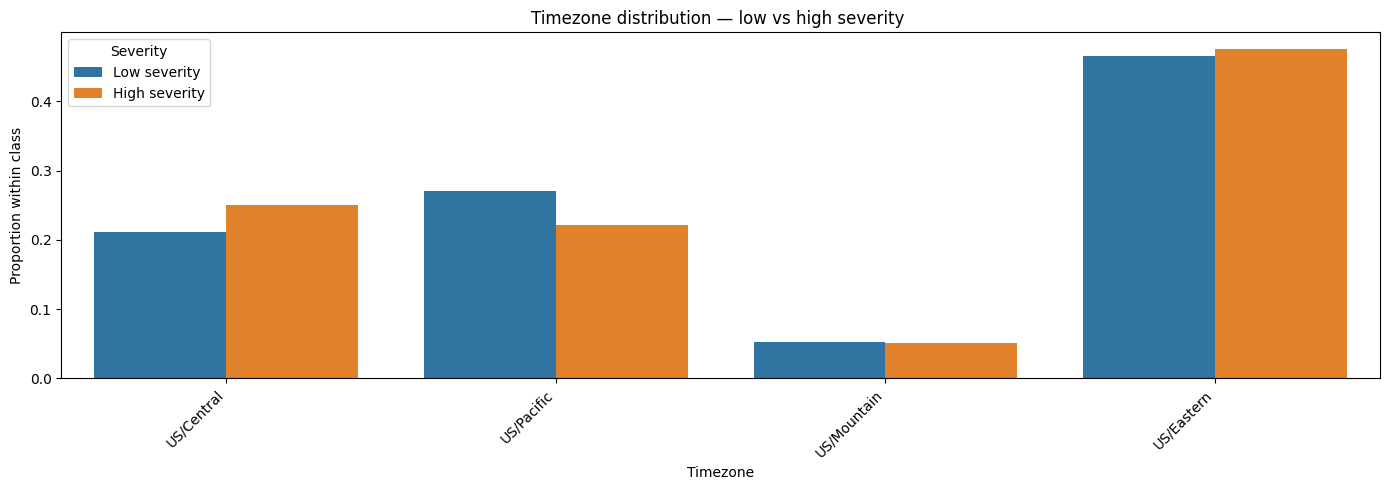


==================== Wind_Direction distribution — low vs high severity  ====================


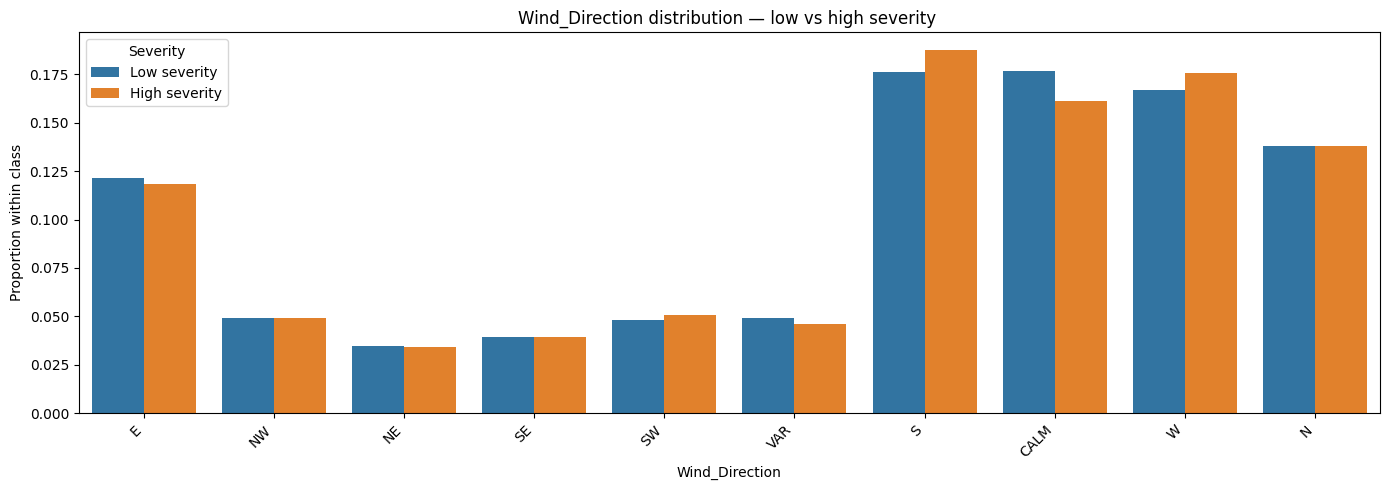


==================== Weather_Condition distribution — low vs high severity (Top 20) ====================


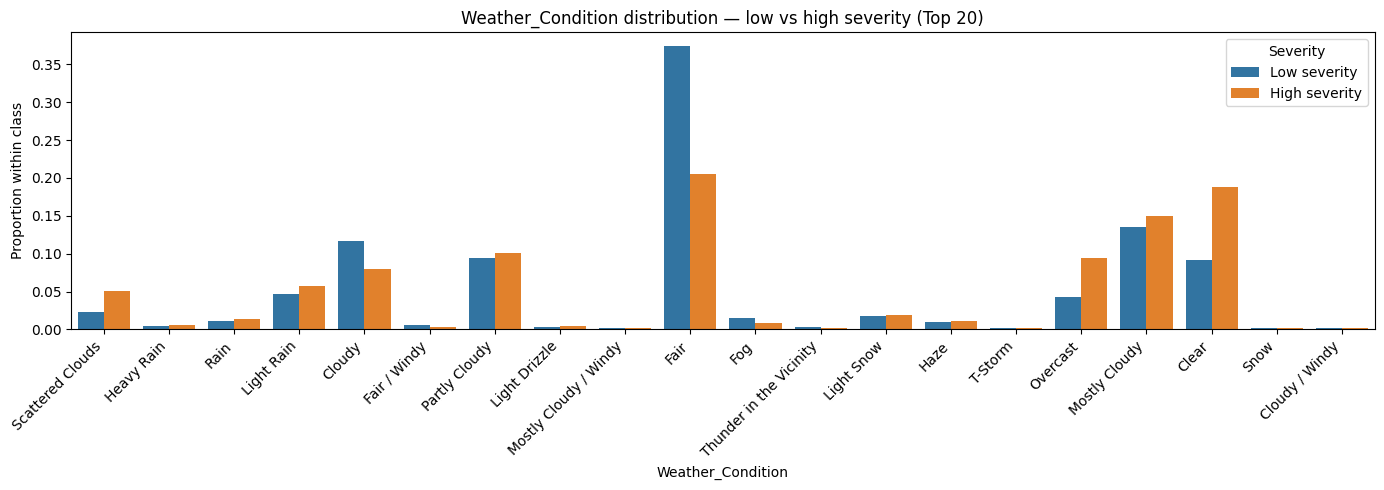


==================== Sunrise_Sunset distribution — low vs high severity  ====================


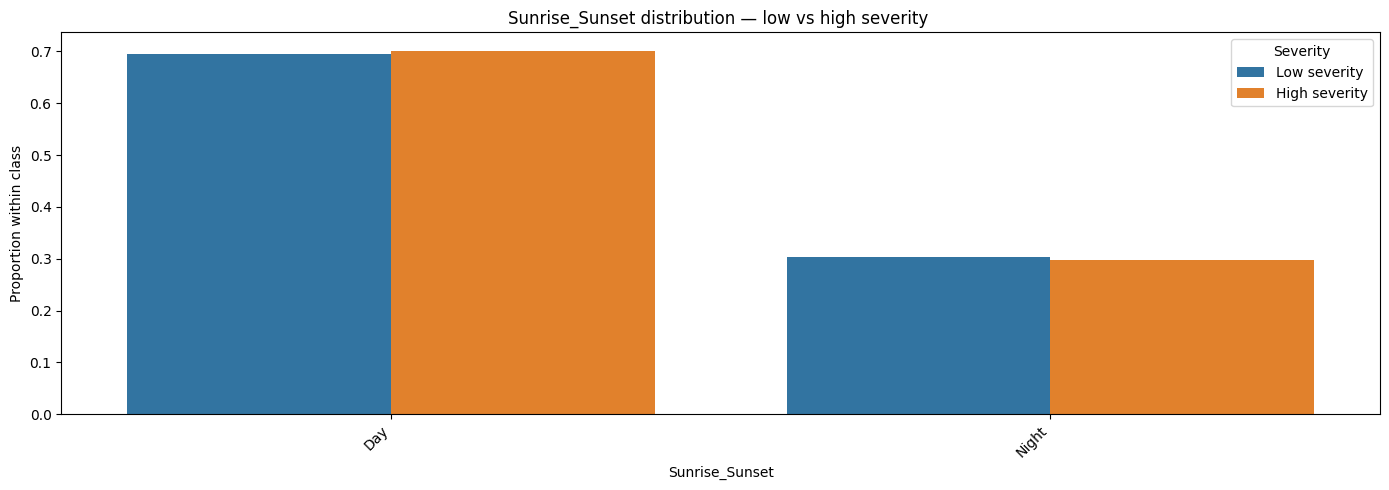


==================== Civil_Twilight distribution — low vs high severity  ====================


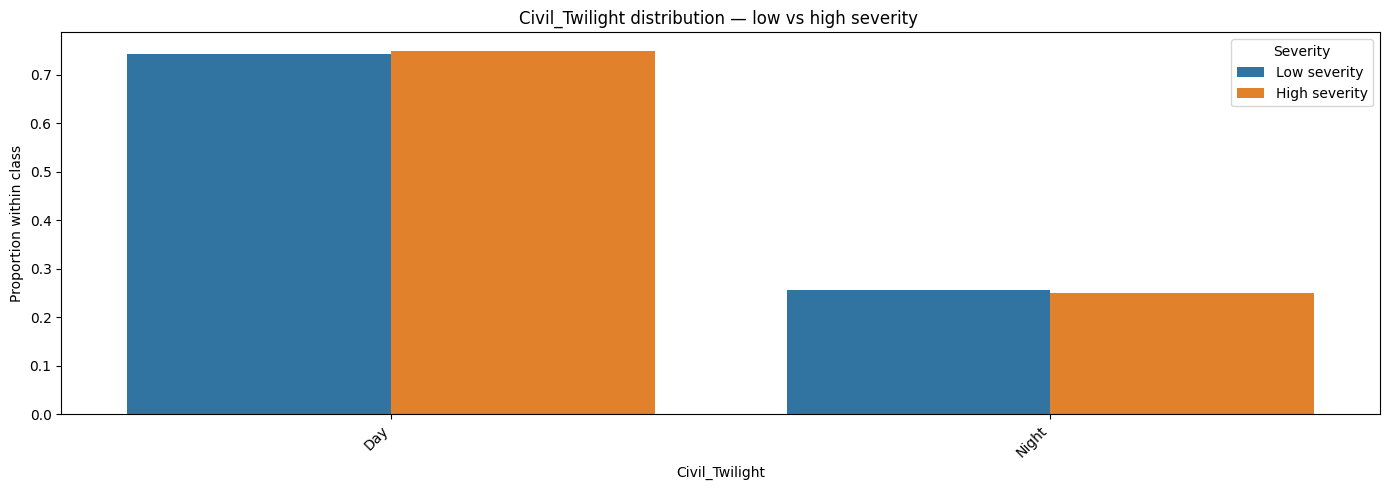


==================== Nautical_Twilight distribution — low vs high severity  ====================


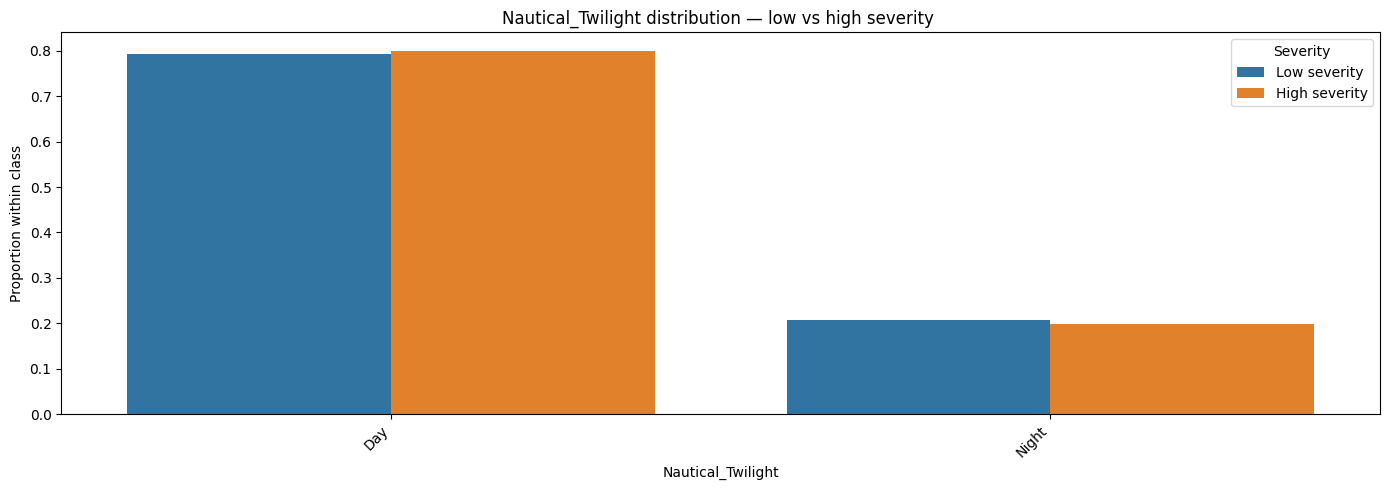


==================== Astronomical_Twilight distribution — low vs high severity  ====================


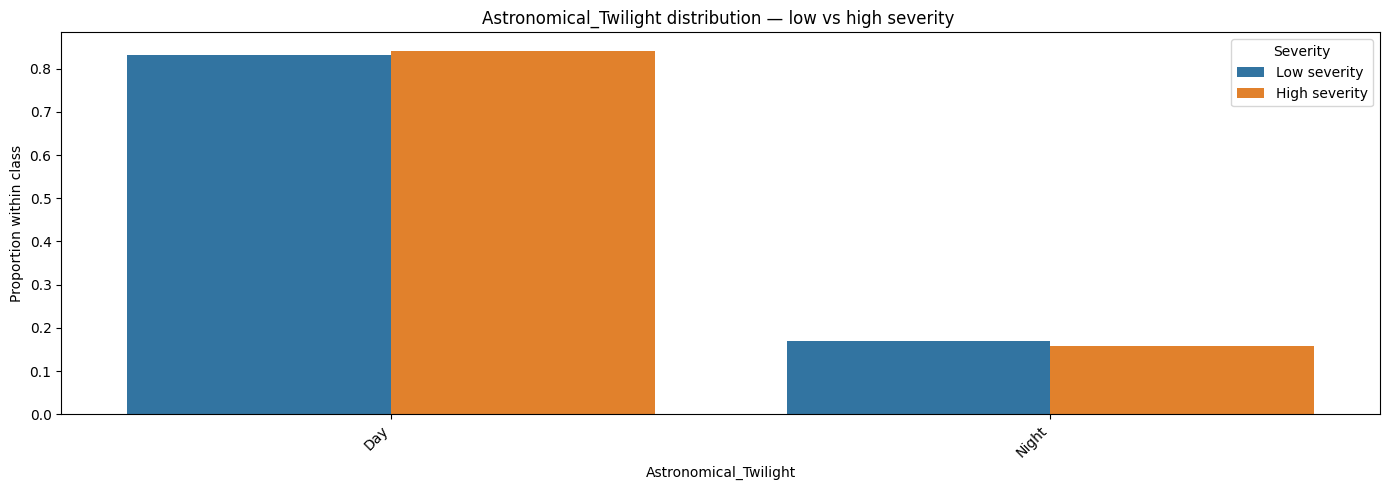

In [11]:
CARDINALITY_THRESHOLD = 20

for c in categorical_col:
    cardinality = df.select(c).distinct().count()
    
    if cardinality > CARDINALITY_THRESHOLD:
        top_vals = [row[c] for row in df.groupBy(c).count() \
            .orderBy(F.desc("count")) \
            .limit(20) \
            .collect()]
        plot_df = df.filter(F.col(c).isin(top_vals))
        title_suffix = "(Top 20)"
    else:
        plot_df = df
        title_suffix = ""

    cat_df = plot_df.groupBy("high_severity", c).count()
    cat_df = cat_df.withColumn("pct", F.col("count") / F.sum("count").over(Window.partitionBy("high_severity")))
    cat_pd = cat_df.toPandas()
    cat_pd["high_severity"] = cat_pd["high_severity"].map({0: "Low severity", 1: "High severity"})

    print()
    border(f"{c} distribution — low vs high severity {title_suffix}")
    plt.figure(figsize=(14, 5))
    sns.barplot(data=cat_pd, x=c, y="pct", hue="high_severity")
    plt.xlabel(c)
    plt.ylabel("Proportion within class")
    plt.title(f"{c} distribution — low vs high severity {title_suffix}")
    plt.legend(title="Severity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

#### Notable Observations

**Geographical Conditions**
* State
    * While California (CA) has the highest proportion of both severity levels, it is disproportionately associated with Low severity accidents.
    * States like Texas (TX), Georgia (GA), Illinois (IL) show a higher relatively proprotion of High severity accidents.
* City, County
    * Log Angeles stands out as a major differentiator at both the City and County level, with a significantly higher proportion of High severity accidents.
    * In constrast, locations such as Miami (City) and Miami-Diade (County) are more associated with Low severity.
* Street
    * Highways such as I-95N, I-95S, and I-80W are hotspots for high severity accidents.

**Weather / Environmental Conditions**
* Wind_Direction
    * Low and High severity accidents show similar distributions across various wind directions, with higher proportions in the main cardinal directions or calm wind.
* Weather_Condition
    * Fair is the most common conditions for all accidents, but is more likely to be the backdrop for a Low severity incident (~37%) than a High one (~21%).
    * Accidents occurring in Clear, Mostly Cloudy, and Overcast weather show ahigher relative proportion within the High severity class.
* Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight
    * * Low and High severity accidents show similar distributions across various daylight thresholds, with higher proportions in the day.

### Correlation Matrix

==================== Pearson correlation matrix - all features ====================


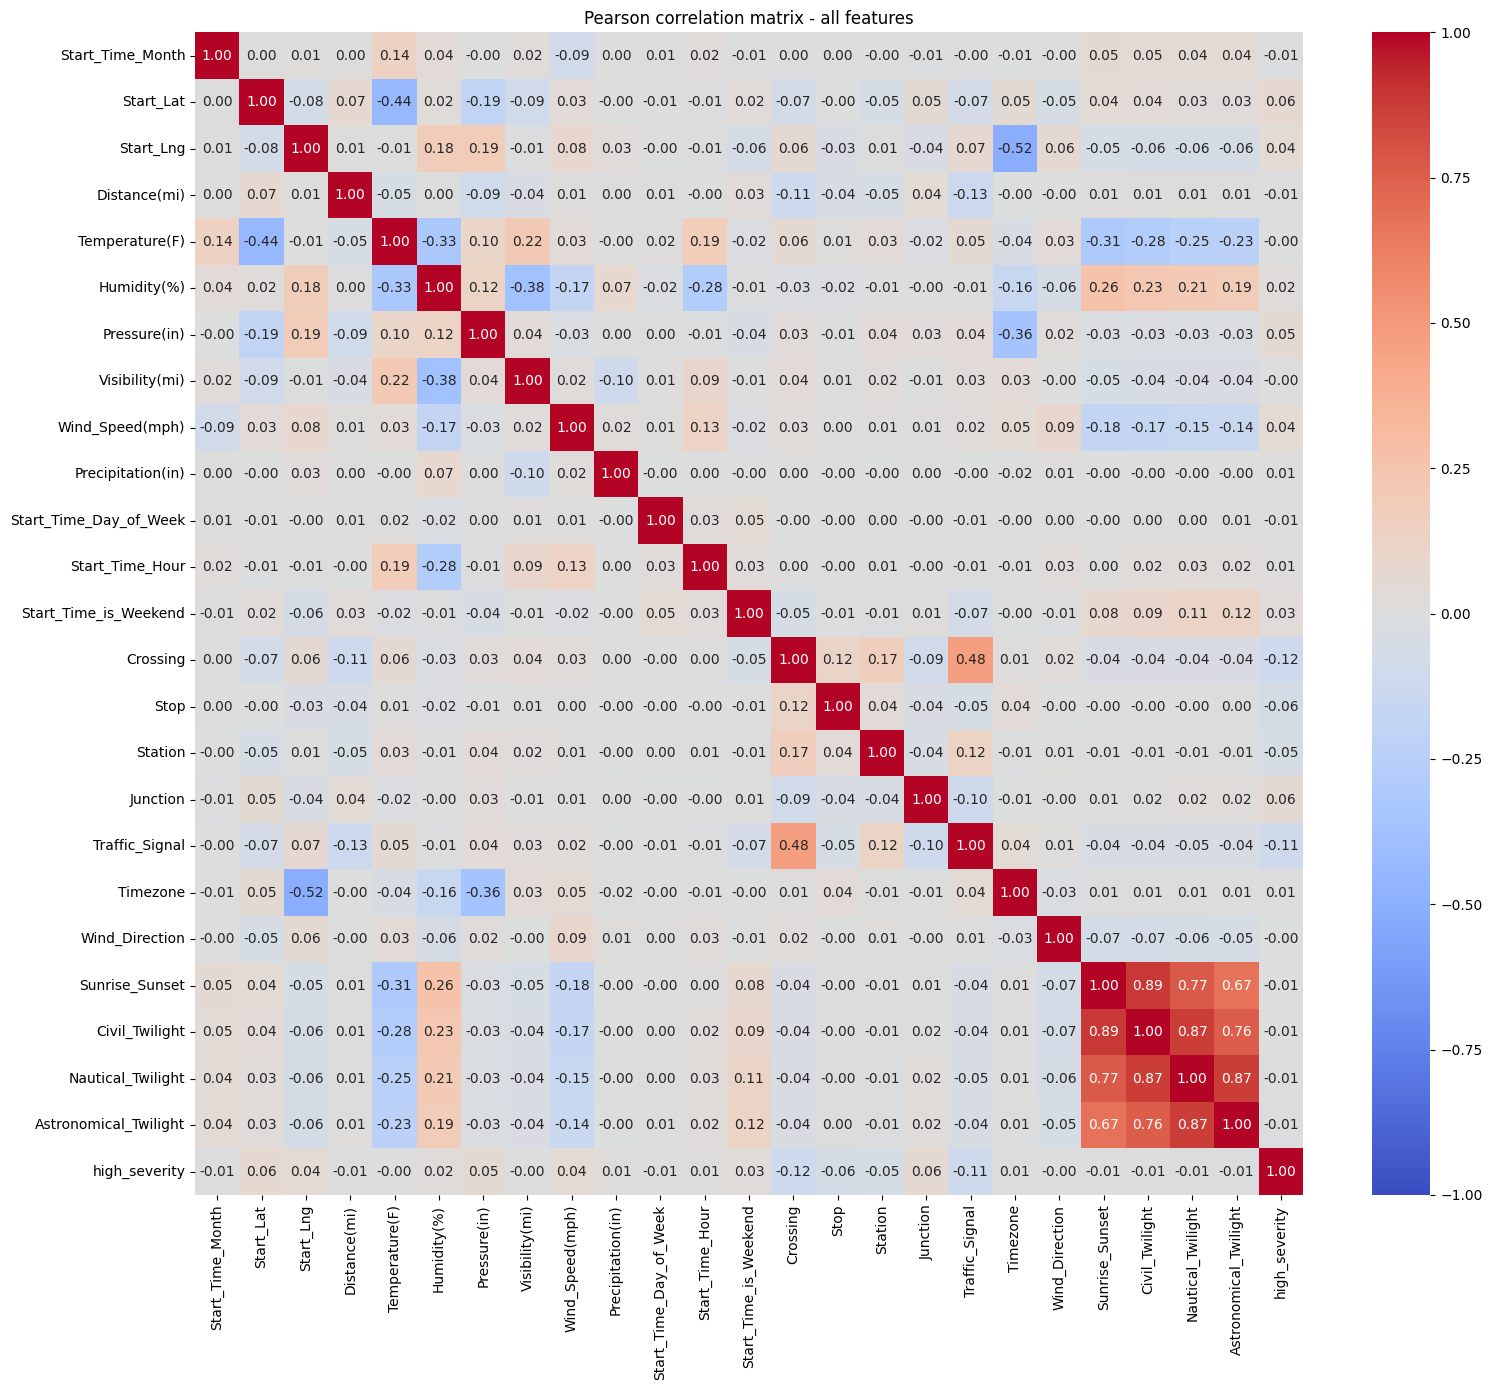

==================== Feature correlation with severity ====================


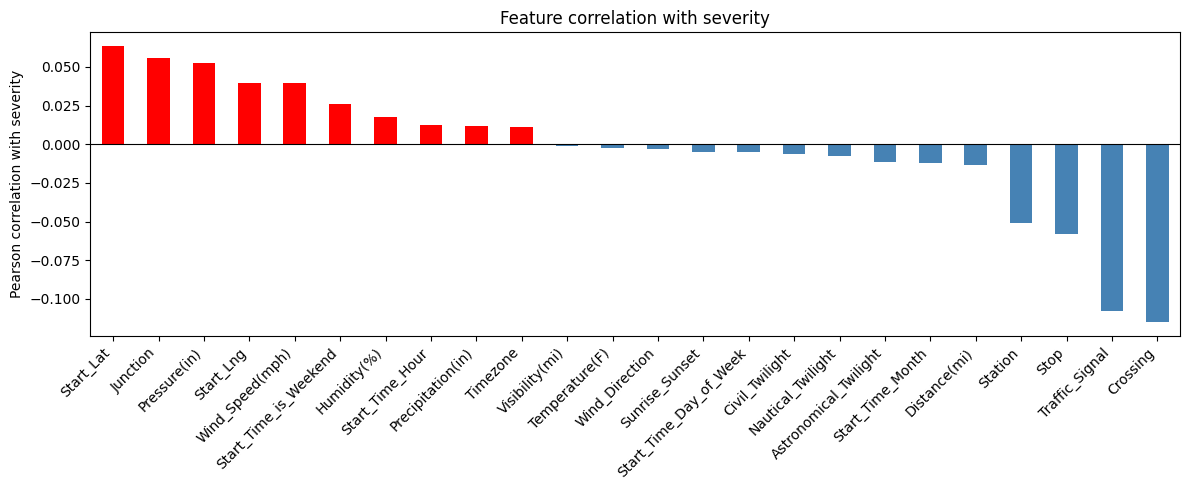

In [12]:
numerical = [c for c in numerical_col if c not in skip]

# Skip high cardinality categoricals
bool_cols = ["Crossing", "Stop", "Station", "Junction", "Traffic_Signal"]
cat_cols = ["Timezone", "Wind_Direction", "Sunrise_Sunset", 
            "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]

for c in bool_cols:
    df = df.withColumn(c + "_int", F.col(c).cast("int"))

indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="skip") 
            for c in cat_cols]
pipeline = Pipeline(stages=indexers)
df_encoded = pipeline.fit(df).transform(df)

bool_int_cols = [c + "_int" for c in bool_cols]
cat_idx_cols = [c + "_idx" for c in cat_cols]
corr_features = numerical + bool_int_cols + cat_idx_cols + ["high_severity"]

assembler = VectorAssembler(inputCols=corr_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df_encoded)
corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()

clean_names = numerical + bool_cols + cat_cols + ["high_severity"]
corr_pd = pd.DataFrame(corr_matrix, index=clean_names, columns=clean_names)

border("Pearson correlation matrix - all features")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation matrix - all features")
plt.tight_layout()
plt.show()

highsev_corr = corr_pd["high_severity"].drop("high_severity").sort_values(ascending=False)

border("Feature correlation with severity")
plt.figure(figsize=(12, 5))
highsev_corr.plot(kind="bar", 
                  color=["red" if v > 0 else "steelblue" for v in highsev_corr])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Pearson correlation with severity")
plt.title("Feature correlation with severity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Conclusion on Features Correlating with Severity

1. **Road Infrastructure Features**  
Infrastructure elements show some of the strongest correlations with accident severity, specifically in differentiating low-speed urban incidents from higher-speed events.

* Crossing & Traffic Signal
    * These are the features most strongly associated with low severity accidents, showing significant negative correlations. They are often concentrated in urban areas with lower traffic speeds.
* Junction
    * This is a key indicator for high severity accidents, showing a notable positive correlation. These likely involve higher-speed maneuvers, such as merging onto highways.
* Stop & Station
    * While having lower absolute correlation values, these features are consistently more common in low severity cases, often representing stop-and-go traffic or proximity to transit hubs during peak travel times.

2. **Spatial and Geographic Features**  
Location data provides critical context for where high-impact accidents are most likely to occur.

* Latitude and Longitude (Start_Lat, Start_Lng)
    * These coordinates show the highest positive correlations with accident severity among numerical features.
* Geographic Identifiers (State, City, County)
    * States like Texas (TX), Georgia (GA), and Illinois (IL) are disproportionately associated with high severity accidents.
    * Los Angeles (both city and county) stands out as a major hotspot for high severity events.

3. **Temporal Features**  
The timing of an accident provides strong signals regarding traffic volume and driver behavior.

* Weekend Status (Start_Time_is_Weekend)
    * High severity accidents show a clear linear trend with weekend occurrence, being significantly more likely to happen on weekends than low severity incidents.
* Hour of Day (Start_Time_Hour)
    * Low severity accidents are heavily concentrated during the morning and evening rush hour (0700 - 0800, 1600 - 1800).
    * High severity accidents are disproportionately represented during late-night and early-morning hours (0000 – 0400).

4. **Weather and Environmental Features**  
Environmental conditions affect both visibility and road traction.

* Atmospheric Pressure (Pressure(in))
    * Shows one of the strongest positive correlations with severity among the recorded weather variables.
* Wind Speed (Wind_Speed(mph))
    * Also shows a positive correlation with higher severity.
* Weather Conditions
    * Categorical data like Fair weather is a strong indicator of low severity (~37% of cases).
    * Clear, Mostly Cloudy, and Overcast conditions are relatively more common in high severity incidents.

## Visualisations for Average Duration (Seconds), Average Distance (Miles) and Accident Count against Severity

In [13]:
summary_df = (
    df
    .groupBy("high_severity")
    .agg(
        F.count("*").alias("Accident_Count"),
        F.round(F.avg("Duration_Seconds"), 2).alias("Avg_Duration_Seconds"),
        F.round(F.avg("Distance(mi)"), 2).alias("Avg_Distance")
    )
    .orderBy("high_severity")
)

summary_df.show()

+-------------+--------------+--------------------+------------+
|high_severity|Accident_Count|Avg_Duration_Seconds|Avg_Distance|
+-------------+--------------+--------------------+------------+
|            0|       5775251|             7258.21|        0.52|
|            1|       1408393|             5315.74|        0.48|
+-------------+--------------+--------------------+------------+



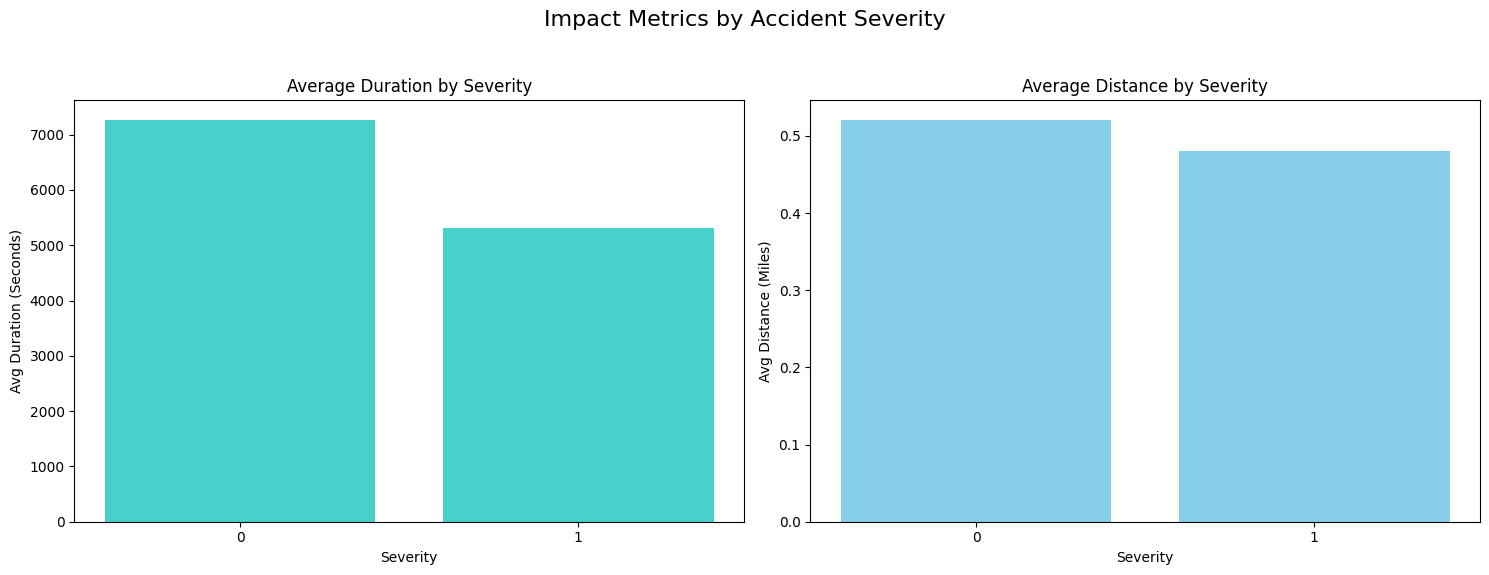

In [14]:
pd = summary_df.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Impact Metrics by Accident Severity", fontsize=16)

axes[0].bar(pd["high_severity"], pd["Avg_Duration_Seconds"], color='mediumturquoise')
axes[0].set_xlabel("Severity")
axes[0].set_xticks([0, 1])
axes[0].set_ylabel("Avg Duration (Seconds)")
axes[0].set_title("Average Duration by Severity")

axes[1].bar(pd["high_severity"], pd["Avg_Distance"], color='skyblue')
axes[1].set_xlabel("Severity")
axes[1].set_xticks([0, 1])
axes[1].set_ylabel("Avg Distance (Miles)")
axes[1].set_title("Average Distance by Severity")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Low and High severity incidents are more differentiated by average duration (7258.21 > 5315.74) than average distance (0.52 > 0.48), with Low severity having higher averages in both categories.


==================== Accident Count ====================


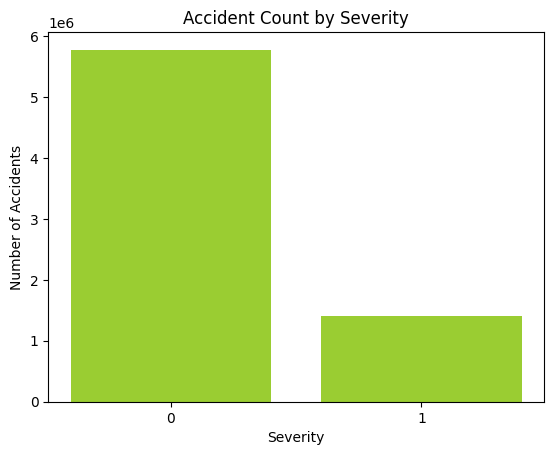

In [15]:
print()
border("Accident Count")
plt.figure()
plt.bar(pd["high_severity"], pd["Accident_Count"], color="yellowgreen")
plt.xlabel("Severity")
plt.xticks([0, 1])
plt.ylabel("Number of Accidents")
plt.title("Accident Count by Severity")
plt.show()

There is a severe class imbalance with Low severity as the majority class. This suggests that a resampling technique such as upsampling of the minority class and downsampling of the majority class should be applied to improve class representation for downstream machine learning.

## Stop Spark

In [ ]:
df.unpersist()
spark.stop()